Parsed 501 entries


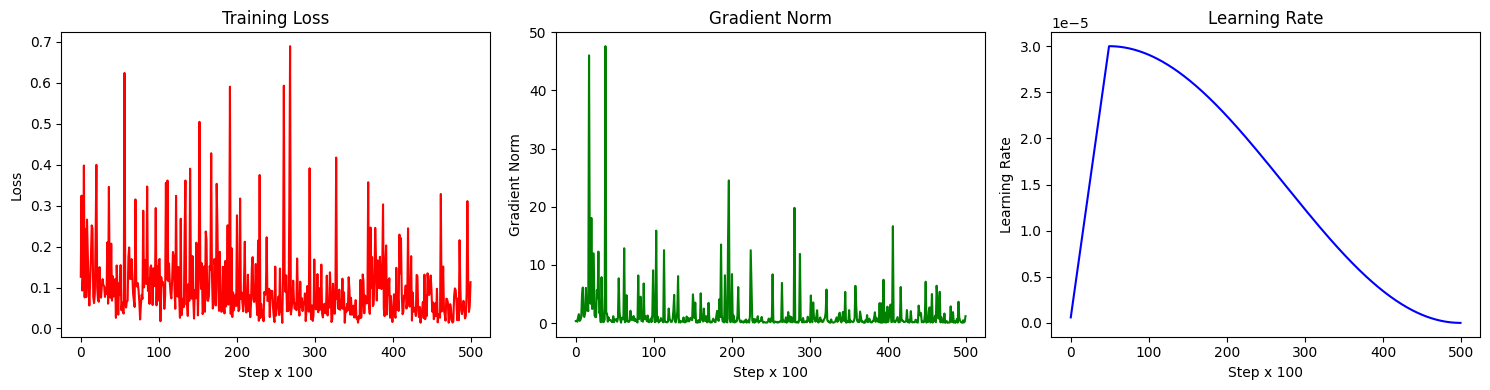

In [2]:
import re
import ast
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load and parse the log
losses = []
grad_norms = []
learning_rates = []

with open("train.log", "r") as f:
    for line in f:
        # Match dictionary-like log lines
        if re.search(r"^\{.*loss.*\}$", line.strip()):
            try:
                log_entry = ast.literal_eval(line.strip())
                losses.append(log_entry.get("loss", None))
                grad_norms.append(log_entry.get("grad_norm", None))
                learning_rates.append(log_entry.get("learning_rate", None))
            except Exception as e:
                print("Skipping malformed line:", line.strip())

# Step 2: Sanity check
print(f"Parsed {len(losses)} entries")

# Step 3: Plot
x = list(range(len(losses)))

plt.figure(figsize=(15, 4))

# Loss
plt.subplot(1, 3, 1)
plt.plot(x, losses, label="Loss", color='red')
plt.xlabel("Step x 100")
plt.ylabel("Loss")
plt.title("Training Loss")

# Grad Norm
plt.subplot(1, 3, 2)
plt.plot(x, grad_norms, label="Grad Norm", color='green')
plt.xlabel("Step x 100")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm")

# Learning Rate
plt.subplot(1, 3, 3)
plt.plot(x, learning_rates, label="Learning Rate", color='blue')
plt.xlabel("Step x 100")
plt.ylabel("Learning Rate")
plt.title("Learning Rate")

plt.tight_layout()
plt.show()

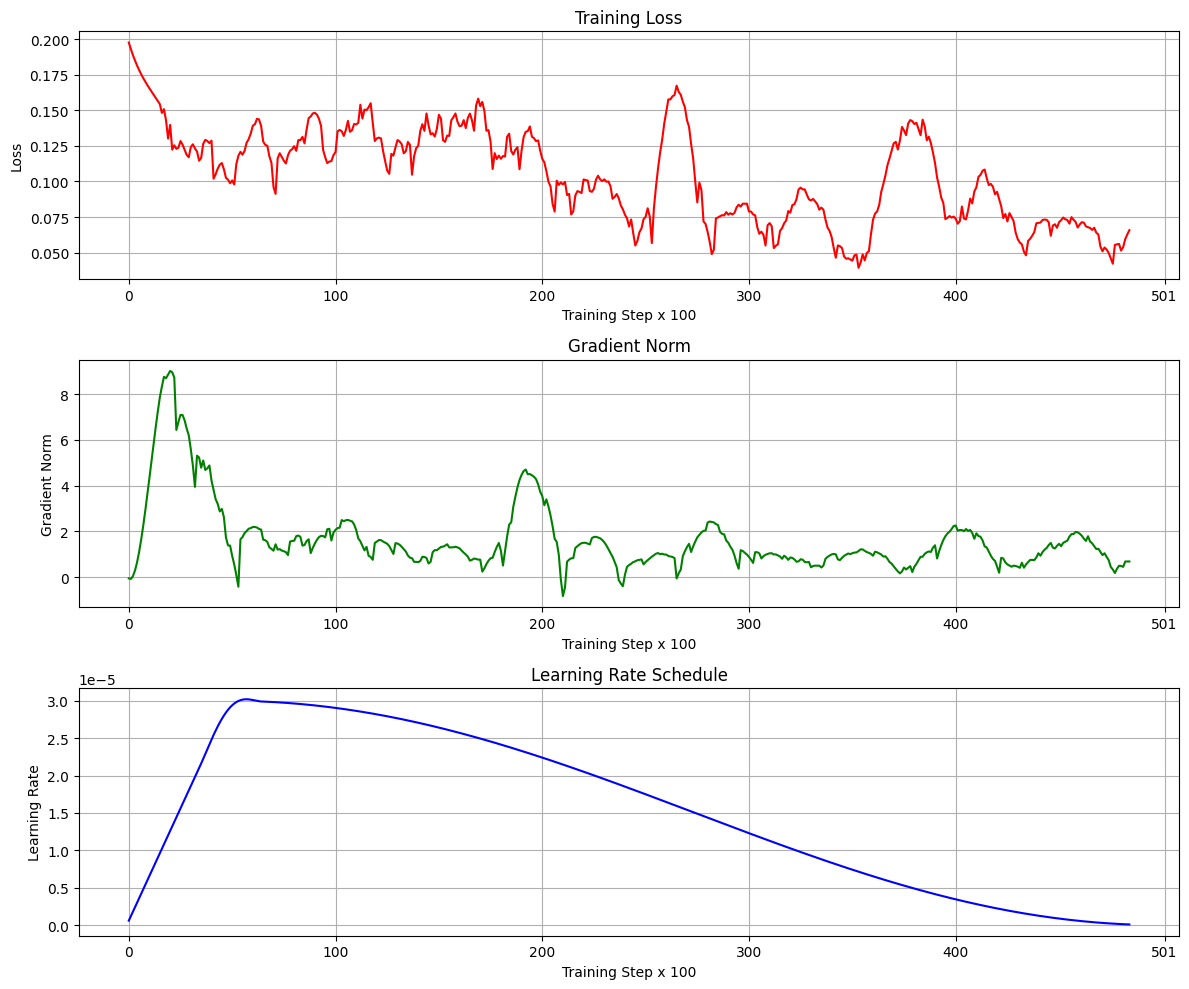

In [6]:
import re
import ast
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# Step 1: Load and parse the log
losses = []
grad_norms = []
learning_rates = []

with open("train.log", "r") as f:
    for line in f:
        if re.search(r"^\{.*loss.*\}$", line.strip()):
            try:
                log_entry = ast.literal_eval(line.strip())
                losses.append(log_entry.get("loss", None))
                grad_norms.append(log_entry.get("grad_norm", None))
                learning_rates.append(log_entry.get("learning_rate", None))
            except Exception as e:
                print("Skipping malformed line:", line.strip())

# Step 2: Convert to arrays
losses = np.array(losses, dtype=np.float32)
grad_norms = np.array(grad_norms, dtype=np.float32)
learning_rates = np.array(learning_rates, dtype=np.float32)
x = np.arange(len(losses))
ticks = np.linspace(0, len(x), 6).astype(int)

# Step 3: Smooth the curves using Savitzky-Golay filter
def smooth(y, window=31, poly=3):
    if len(y) < window:
        return y  # skip smoothing if data too short
    return savgol_filter(y, window_length=window, polyorder=poly)

loss_smooth = smooth(losses)
grad_smooth = smooth(grad_norms)
lr_smooth = smooth(learning_rates)

# Step 4: Plot vertically
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(12, 10))

# Plot: Loss
axs[0].plot(x, loss_smooth, color="red")
# axs[0].fill_between(x, loss_smooth * 0.95, loss_smooth * 1.05, color='red', alpha=0.1)
axs[0].set_title("Training Loss")
axs[0].set_xlabel("Training Step x 100")
axs[0].set_ylabel("Loss")
axs[0].set_xticks(ticks)
axs[0].grid(True)

# Plot: Gradient Norm
axs[1].plot(x, grad_smooth, color="green")
# axs[1].fill_between(x, grad_smooth * 0.9, grad_smooth * 1.1, color='green', alpha=0.1)
axs[1].set_title("Gradient Norm")
axs[1].set_xlabel("Training Step x 100")
axs[1].set_ylabel("Gradient Norm")
axs[1].set_xticks(ticks)
axs[1].grid(True)

# Plot: Learning Rate
axs[2].plot(x, lr_smooth, color="blue")
axs[2].set_title("Learning Rate Schedule")
axs[2].set_xlabel("Training Step x 100")
axs[2].set_ylabel("Learning Rate")
axs[2].set_xticks(ticks)
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [2]:
import plotly.graph_objects as go

# Labels for the nodes
labels = [
    "Original scGPT\n(51.4M)",     # 0
    "PEFT (LoRA)\n(51.4M)",        # 1
    "Trainable\n(Full Model)",     # 2
    "Trainable\n(LoRA)",           # 3
    "Frozen\nParameters"           # 4
]

# Define links between source and target nodes
sources = [0, 1, 1]
targets = [2, 3, 4]
values = [51_381_346, 349_681, 51_031_665]

# Optional: Define custom colors for flows
link_colors = ["#636EFA", "#00CC96", "#AB63FA"]

# Create Sankey plot
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=18,
        thickness=25,
        line=dict(color="black", width=0.5),
        label=labels,
        color=["#636EFA", "#00CC96", "#636EFA", "#00CC96", "#B0BEC5"]
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

# Update layout for publication
fig.update_layout(
    title_text="Parameter Flow: Full Finetuning vs. PEFT (LoRA)",
    font=dict(size=14, family="Arial"),
    margin=dict(l=40, r=40, t=60, b=40),
    height=400,
    width=800,
    paper_bgcolor='white'
)

fig.show()

In [24]:
!pip install nbformat>=4.2.0